In [6]:
import random
import csv
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split

In [3]:
# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Dataset location
DATA_DIR = Path("data/garbage_classification")

# Output folder for shared split files
SPLITS_DIR = Path("data/splits")
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

# Split ratios
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

print(f"data dir: {DATA_DIR}")
print(f"exists  : {DATA_DIR.exists()}")
print(f"splits  : {SPLITS_DIR}")

data dir: data/garbage_classification
exists  : True
splits  : data/splits


##  Scan Dataset

In [4]:
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATA_DIR}\n"
        "Expected structure: data/garbage_classification/<class folders>/<images>"
    )

# Get classes
class_list = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
class_to_idx = {class_name: i for i, class_name in enumerate(class_list)}

# Collect every image path and its integer class label
all_paths = []
all_labels = []

for class_name in class_list:
    class_dir = DATA_DIR / class_name

    for img_path in sorted(class_dir.iterdir()):
        # Skip hidden files/folders such as .ipynb_checkpoints
        if any(part.startswith(".") for part in img_path.parts):
            continue

        if img_path.is_file() and img_path.suffix.lower() in IMAGE_EXTENSIONS:
            all_paths.append(str(img_path))
            all_labels.append(class_to_idx[class_name])

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

print(f"classes ({len(class_list)}): {class_list}")
print(f"total images: {len(all_paths)}")

if len(all_paths) > 0:
    print(f"first sample: {all_paths[0]}")
    print(f"              -> label={all_labels[0]} ({class_list[all_labels[0]]})")

classes (12): ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']
total images: 15515
first sample: data/garbage_classification/battery/battery1.jpg
              -> label=0 (battery)


Saved: final_evaluation/figures/sample_images_by_class.png


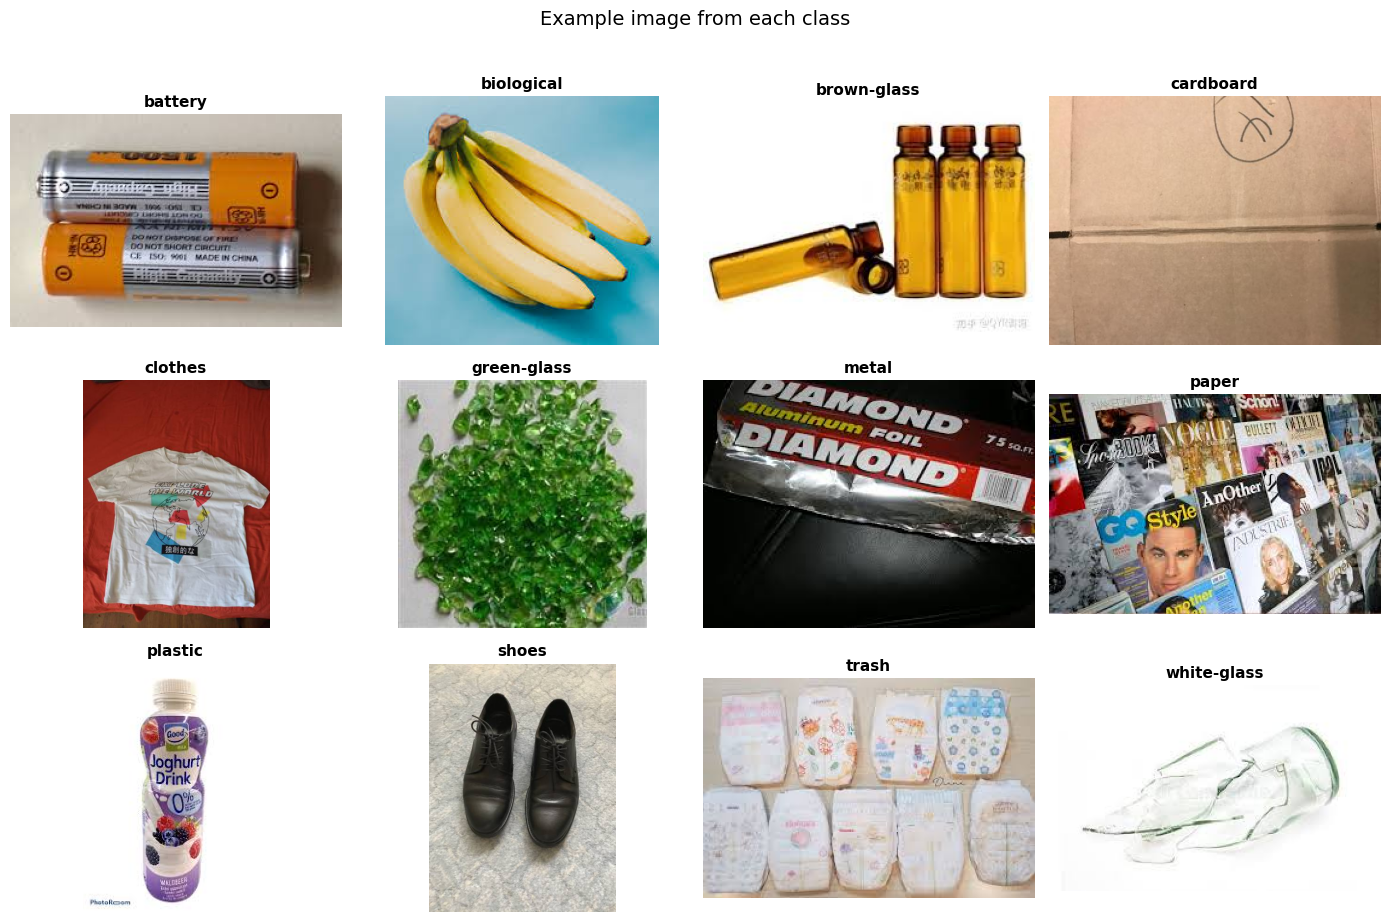

In [17]:
# Display one example of each class in a 3 x 4 grid
image_extensions = {".jpg", ".jpeg", ".png"}

n_rows = 3
n_cols = 4

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 9),
    squeeze=False,
)

for idx, class_name in enumerate(class_list):
    row_idx = idx // n_cols
    col_idx = idx % n_cols

    ax = axes[row_idx, col_idx]
    class_dir = DATA_DIR / class_name

    image_files = [
        p for p in sorted(class_dir.iterdir())
        if p.suffix.lower() in image_extensions
    ]

    if len(image_files) == 0:
        ax.set_title(f"{class_name}\n(no image found)", fontsize=10)
        ax.axis("off")
        continue

    img = Image.open(image_files[0]).convert("RGB")

    ax.imshow(img)
    ax.set_title(class_name, fontsize=11, fontweight="bold")
    ax.axis("off")

fig.suptitle("Example image from each class", fontsize=14, y=1.02)
plt.tight_layout()

save_path = "final_evaluation/figures/sample_images_by_class.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print("Saved:", save_path)

plt.show()

## Class Imbalance

Class distribution:
          battery:   945
       biological:   985
      brown-glass:   607
        cardboard:   891
          clothes:  5325
      green-glass:   629
            metal:   769
            paper:  1050
          plastic:   865
            shoes:  1977
            trash:   697
      white-glass:   775

max class : clothes (5325 images)
min class : brown-glass (607 images)
imbalance ratio (max / min): 8.77x


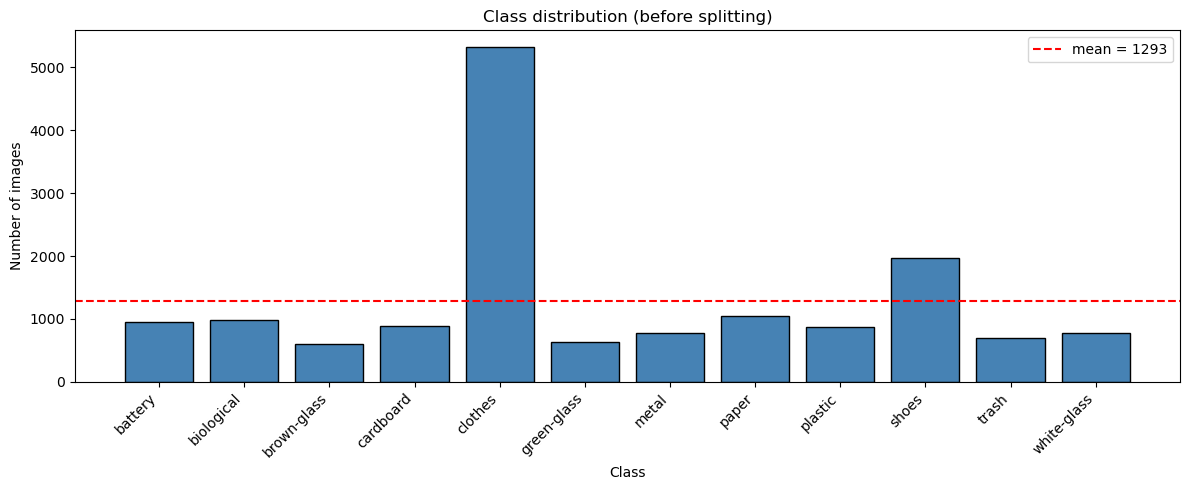

In [13]:
counts = Counter(all_labels)
class_counts = np.array([counts[i] for i in range(len(class_list))])

print("Class distribution:")
for i, class_name in enumerate(class_list):
    print(f"  {class_name:>15s}: {class_counts[i]:>5d}")

max_idx = class_counts.argmax()
min_idx = class_counts.argmin()

print()
print(f"max class : {class_list[max_idx]} ({class_counts[max_idx]} images)")
print(f"min class : {class_list[min_idx]} ({class_counts[min_idx]} images)")
print(f"imbalance ratio (max / min): {class_counts[max_idx] / class_counts[min_idx]:.2f}x")

# Visualise class distribution
fig = plt.figure(figsize=[12, 5])
ax  = fig.add_subplot(1, 1, 1)
ax.bar(class_list, class_counts, color='steelblue', edgecolor='black')
ax.axhline(y=class_counts.mean(), color='red', linestyle='--',
           label=f'mean = {class_counts.mean():.0f}')
ax.set_ylabel('Number of images')
ax.set_xlabel('Class')
ax.set_title('Class distribution (before splitting)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Stratified train/validation/test split

In [14]:
# Step 1: train+val vs test
trainval_paths, test_paths, trainval_labels, test_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=TEST_SIZE,
    stratify=all_labels,
    random_state=RANDOM_STATE,
    shuffle=True,
)

# Step 2: train vs validation
# val_ratio is relative to the train+val subset
val_ratio = VAL_SIZE / (1.0 - TEST_SIZE)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    trainval_paths,
    trainval_labels,
    test_size=val_ratio,
    stratify=trainval_labels,
    random_state=RANDOM_STATE,
    shuffle=True,
)

print(f"train: {len(train_paths):>5d}  ({len(train_paths) / len(all_paths) * 100:.1f}%)")
print(f"val  : {len(val_paths):>5d}  ({len(val_paths) / len(all_paths) * 100:.1f}%)")
print(f"test : {len(test_paths):>5d}  ({len(test_paths) / len(all_paths) * 100:.1f}%)")
print(f"total: {len(all_paths):>5d}")

train: 10859  (70.0%)
val  :  2328  (15.0%)
test :  2328  (15.0%)
total: 15515


In [15]:
# Verify split overlap
train_set = set(train_paths)
val_set = set(val_paths)
test_set = set(test_paths)

print("train/val overlap :", len(train_set & val_set))
print("train/test overlap:", len(train_set & test_set))
print("val/test overlap  :", len(val_set & test_set))

assert len(train_set & val_set) == 0
assert len(train_set & test_set) == 0
assert len(val_set & test_set) == 0

print("No overlap between train, validation, and test splits.")

train/val overlap : 0
train/test overlap: 0
val/test overlap  : 0
No overlap between train, validation, and test splits.


          class    train    val   test   total
--------------------------------------------------
        battery      661    142    142     945
     biological      689    148    148     985
    brown-glass      425     91     91     607
      cardboard      623    134    134     891
        clothes     3727    799    799    5325
    green-glass      441     94     94     629
          metal      539    115    115     769
          paper      735    158    157    1050
        plastic      605    130    130     865
          shoes     1383    297    297    1977
          trash      488    104    105     697
    white-glass      543    116    116     775
--------------------------------------------------
          TOTAL    10859   2328   2328   15515


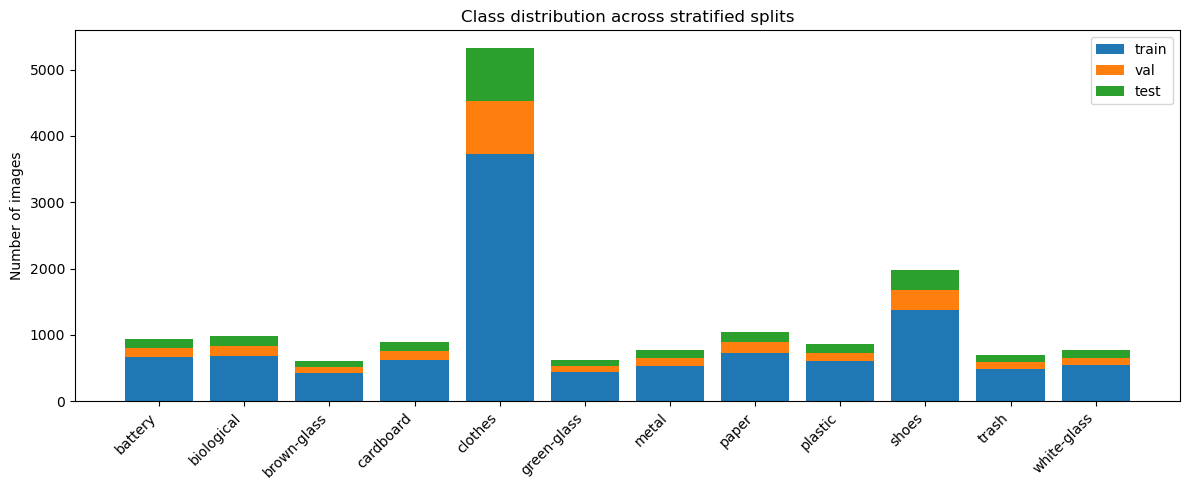

In [16]:
# Per-class split summary
print(f'{"class":>15s}  {"train":>7s}  {"val":>5s}  {"test":>5s}  {"total":>6s}')
print("-" * 50)

summary_rows = []

for i, class_name in enumerate(class_list):
    n_train = int((train_labels == i).sum())
    n_val = int((val_labels == i).sum())
    n_test = int((test_labels == i).sum())
    n_total = n_train + n_val + n_test

    summary_rows.append({
        "class_name": class_name,
        "label": i,
        "train": n_train,
        "val": n_val,
        "test": n_test,
        "total": n_total,
    })

    print(f"{class_name:>15s}  {n_train:>7d}  {n_val:>5d}  {n_test:>5d}  {n_total:>6d}")

print("-" * 50)
print(f'{"TOTAL":>15s}  {len(train_labels):>7d}  {len(val_labels):>5d}  {len(test_labels):>5d}  {len(all_labels):>6d}')

split_summary_df = pd.DataFrame(summary_rows)

# Plot split distribution
train_counts = np.array([(train_labels == i).sum() for i in range(len(class_list))])
val_counts = np.array([(val_labels == i).sum() for i in range(len(class_list))])
test_counts = np.array([(test_labels == i).sum() for i in range(len(class_list))])

fig = plt.figure(figsize=[12, 5])
ax = fig.add_subplot(1, 1, 1)

x = np.arange(len(class_list))

ax.bar(x, train_counts, label="train")
ax.bar(x, val_counts, bottom=train_counts, label="val")
ax.bar(x, test_counts, bottom=train_counts + val_counts, label="test")

ax.set_xticks(x)
ax.set_xticklabels(class_list, rotation=45, ha="right")
ax.set_ylabel("Number of images")
ax.set_title("Class distribution across stratified splits")
ax.legend()

plt.tight_layout()
plt.show()

## Save split files

In [17]:
def save_split_csv(paths, labels, csv_path):
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["path", "label", "class_name"])

        for path, label in zip(paths, labels):
            relative_path = Path(path).relative_to(DATA_DIR).as_posix()
            class_name = class_list[int(label)]
            writer.writerow([relative_path, int(label), class_name])

    print(f"saved: {csv_path} ({len(paths)} rows)")


save_split_csv(train_paths, train_labels, SPLITS_DIR / "train.csv")
save_split_csv(val_paths, val_labels, SPLITS_DIR / "val.csv")
save_split_csv(test_paths, test_labels, SPLITS_DIR / "test.csv")

saved: data/splits/train.csv (10859 rows)
saved: data/splits/val.csv (2328 rows)
saved: data/splits/test.csv (2328 rows)


In [18]:
# Reload data for sanity check
train_df = pd.read_csv(SPLITS_DIR / "train.csv")
val_df = pd.read_csv(SPLITS_DIR / "val.csv")
test_df = pd.read_csv(SPLITS_DIR / "test.csv")

print("train:", train_df.shape)
print("val  :", val_df.shape)
print("test :", test_df.shape)

display(train_df.head())

train: (10859, 3)
val  : (2328, 3)
test : (2328, 3)


,path,label,class_name
0,clothes/clothes3810.jpg,4,clothes
1,clothes/clothes496.jpg,4,clothes
2,clothes/clothes2829.jpg,4,clothes
3,clothes/clothes5295.jpg,4,clothes
4,paper/paper830.jpg,7,paper
